# Allocations that estimate less

**Docker image**: `ml4t`

## Purpose
`02_mean_variance_optimization` ends on a problem: the optimizer's answer is dominated by the
input estimated worst, and it responds by putting almost everything into two assets. The
responses to that problem fall into two families, and this notebook runs both.

The first improves the estimate. Ledoit-Wolf shrinkage pulls the sample covariance towards a
structured target, accepting a known bias in exchange for far less variation from sample to
sample. The second changes the objective so it needs less. Risk parity, minimum variance and
minimum conditional drawdown all drop the expected-return vector entirely and optimize against
risk alone; equal weight optimizes against nothing.

Every one of them is fitted on a training window, frozen, and scored on a later one, alongside
an execution bridge that says what implementing one of them would have cost.

## Learning objectives

- Fit a shrunk covariance estimator and say what the shrinkage buys and what it costs.
- Build allocations that equalize risk contribution, minimize variance, and minimize tail loss,
  and say which inputs each one needs.
- Measure concentration as a number rather than by eye, and use it to compare methods that
  estimate different amounts.
- Check whether an allocation fitted to a training drawdown actually has a shallow one later.

## Book reference
Chapter 17, Section 17.5 (mean-variance optimization and the Markowitz curse).

## Prerequisites

- `02_mean_variance_optimization`, which sets up the problem these methods answer.
- Daily ETF prices from the canonical dataset.

## Setup

In [1]:
"""Compare Riskfolio-Lib allocators with Ledoit-Wolf shrinkage, risk contributions, rolling Sharpe, and an execution bridge."""

import warnings

warnings.filterwarnings("ignore")

import cvxpy.reductions.matrix_stuffing as cvxpy_matrix_stuffing
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
import riskfolio as rp
from cvxpy.problems.problem import Problem as _CvxpyProblem
from ml4t.backtest import (
    BacktestConfig,
    CommissionType,
    DataFeed,
    Engine,
    ExecutionMode,
    Strategy,
)
from ml4t.backtest.config import SlippageType
from ml4t.backtest.execution.rebalancer import RebalanceConfig, TargetWeightExecutor

# Evaluation
from ml4t.diagnostic.evaluation import (
    PortfolioAnalysis,
)

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, ml4t_diverging, ml4t_palette

Riskfolio-Lib reaches CVXPY through an interface that changed across CVXPY versions, so the
check below reports a version mismatch as an environment problem rather than letting it surface
later as an unexplained solver failure.

In [2]:
missing_cvxpy_symbols = [
    name
    for name in ("extract_lower_bounds", "extract_upper_bounds")
    if not hasattr(cvxpy_matrix_stuffing, name)
]
if not hasattr(_CvxpyProblem, "_supports_cpp"):
    missing_cvxpy_symbols.append("Problem._supports_cpp")
if missing_cvxpy_symbols:
    raise RuntimeError(
        "Incompatible cvxpy runtime for Riskfolio-Lib. Install the supported CVXPY stack. "
        f"Missing symbols: {missing_cvxpy_symbols}"
    )

In [3]:
# Production defaults; Papermill overrides for CI testing
SEED = 42
TRAIN_END = "2019-12-31"
COMMISSION_RATE = 0.0005
SLIPPAGE_RATE = 0.0005

In [4]:
set_global_seeds(SEED)

## 1. Data Acquisition

Eleven exchange-traded funds, one per broad exposure: US large, mid and small caps, developed
and emerging markets outside the US, aggregate and long-dated Treasuries, high-yield credit,
gold, property and commodities. Each is already a diversified basket, so allocating across them
is an asset-allocation decision and the estimation problem shows up without the separate problem
of picking individual securities. The narrower universe is deliberate: eleven assets need 55
covariances estimated where the previous notebook's thirty need 435.

In [5]:
# Multi-asset ETF universe
ETF_UNIVERSE = {
    # US Equity
    "SPY": "S&P 500",
    "QQQ": "NASDAQ 100",
    "IWM": "Russell 2000",
    # International Equity
    "EFA": "EAFE (Developed)",
    "EEM": "Emerging Markets",
    # Fixed Income
    "AGG": "US Aggregate Bond",
    "TLT": "Long Treasury",
    "HYG": "High Yield Corporate",
    # Alternatives
    "GLD": "Gold",
    "VNQ": "Real Estate",
    "DBC": "Commodities",
}

SYMBOLS = list(ETF_UNIVERSE.keys())
START_DATE = "2015-01-01"
END_DATE = "2023-12-31"

In [6]:
# Load the fixed teaching universe from canonical ETF data.
etf_data = load_etfs(symbols=SYMBOLS, start_date=START_DATE, end_date=END_DATE)
prices = (
    etf_data.select(["timestamp", "symbol", "close"])
    .pivot(on="symbol", index="timestamp", values="close")
    .sort("timestamp")
    .fill_null(strategy="forward")
    .drop_nulls()
    .select(["timestamp", *SYMBOLS])
)
close_prices = prices.to_pandas().set_index("timestamp")
print(f"Loaded {len(close_prices):,} days for {close_prices.shape[1]} ETFs")

Loaded 2,264 days for 11 ETFs


In [7]:
# Compute returns once so the first test return retains the final training close as its denominator.
returns = close_prices.pct_change().dropna()
train_returns = returns.loc[:TRAIN_END]
test_returns = returns.loc[returns.index > TRAIN_END]

if train_returns.empty or test_returns.empty:
    raise ValueError("Both train and test windows must contain returns")
if train_returns.index.max() >= test_returns.index.min():
    raise ValueError("Train and test windows overlap")

print(
    f"Training returns: {train_returns.index.min().date()} to "
    f"{train_returns.index.max().date()} ({len(train_returns):,} observations)"
)
print(
    f"Test returns: {test_returns.index.min().date()} to "
    f"{test_returns.index.max().date()} ({len(test_returns):,} observations)"
)

Training returns: 2015-01-05 to 2019-12-31 (1,257 observations)
Test returns: 2020-01-02 to 2023-12-29 (1,006 observations)


This fixed universe intentionally mixes equities, duration, credit, and real assets.
It uses current-vintage ETF history rather than point-in-time historical membership,
so the exercise demonstrates allocator mechanics rather than a survivorship-free strategy test.

## 2. Correlation Analysis

Only training observations enter the correlation map and every fitted allocator below.

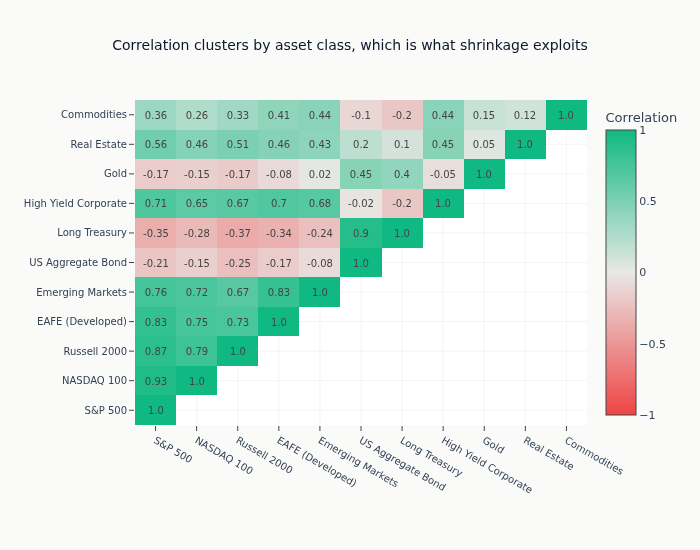

In [8]:
# Training-period correlation matrix with the redundant upper triangle masked.
corr_matrix = train_returns.corr()
corr_values = corr_matrix.to_numpy()
mask = np.triu(np.ones_like(corr_values, dtype=bool), k=1)
heatmap_values = np.where(mask, np.nan, corr_values)
heatmap_text = np.where(mask, "", np.round(corr_values, 2).astype(str))
off_diagonal = corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool)).stack()
strongest_pair = off_diagonal.idxmax()
strongest_corr = float(off_diagonal.max())

fig = go.Figure(
    data=go.Heatmap(
        z=heatmap_values,
        x=[ETF_UNIVERSE[s] for s in corr_matrix.columns],
        y=[ETF_UNIVERSE[s] for s in corr_matrix.index],
        colorscale=ml4t_diverging(),
        zmid=0,
        zmin=-1,
        zmax=1,
        text=heatmap_text,
        texttemplate="%{text}",
        textfont={"size": 10},
        hoverongaps=False,
        colorbar=dict(title="Correlation"),
    )
)

fig.update_layout(
    title="Correlation clusters by asset class, which is what shrinkage exploits",
    height=550,
    margin=dict(l=135, b=125, r=40),
)
fig.show()

## 3. Portfolio Optimization Setup

Riskfolio-Lib receives pandas only at its API boundary. Historical expected returns
and Ledoit-Wolf covariance are estimated on the training window; the hurdle is zero.

## 4. Optimization Methods Comparison

We compare six portfolio optimization approaches. The risk parity objective minimizes
the dispersion of risk contributions:

$$\min_w \sum_{i=1}^{N} \left( w_i \cdot (\Sigma w)_i - \frac{w^\top \Sigma w}{N} \right)^2$$

where $(\Sigma w)_i$ is asset $i$'s marginal risk contribution. At optimality, each asset
contributes equally to portfolio variance.

1. **Mean-Variance (Max Sharpe)**
2. **Minimum Variance**
3. **Risk Parity (ERC)**
4. **Hierarchical Risk Parity (HRP)**
5. **Min CDaR** (tail-risk optimization)
6. **Equal Weight (Benchmark)**

In [9]:
OPTIMIZATION_SPECS = {
    "max_sharpe": {
        "name": "Max Sharpe (MVO)",
        "call": lambda port: port.optimization(
            model="Classic", rm="MV", obj="Sharpe", rf=0, hist=True
        ),
    },
    "min_variance": {
        "name": "Minimum Variance",
        "call": lambda port: port.optimization(
            model="Classic", rm="MV", obj="MinRisk", rf=0, hist=True
        ),
    },
    "risk_parity": {
        "name": "Risk Parity",
        "call": lambda port: port.rp_optimization(model="Classic", rm="MV", rf=0, hist=True),
    },
    "min_cdar": {
        "name": "Min CDaR",
        "call": lambda port: port.optimization(
            model="Classic", rm="CDaR", obj="MinRisk", rf=0, hist=True
        ),
    },
}

Riskfolio-Lib names each objective by a pair of strings - a risk measure and what to do with
it - so the table below is the translation from the six methods named above into the calls that
produce them.

In [10]:
def optimize_portfolio(method: str, fit_returns: pd.DataFrame) -> dict:
    """Fit one robust allocation method on the supplied return window."""
    if method == "equal_weight":
        weights = {symbol: 1 / len(SYMBOLS) for symbol in SYMBOLS}
        return {"name": "Equal Weight", "weights": weights, "covariance": None}

    if method == "hrp":
        w = rp.HCPortfolio(returns=fit_returns).optimization(
            model="HRP",
            codependence="pearson",
            rm="MV",
            rf=0,
            linkage="ward",
            max_k=10,
            leaf_order=True,
            method_cov="ledoit",
        )
        weights = w["weights"].to_dict() if w is not None else None
        return {"name": "HRP", "weights": weights, "covariance": None}

    if method not in OPTIMIZATION_SPECS:
        raise ValueError(f"Unknown method: {method}")

    port = rp.Portfolio(returns=fit_returns)
    port.assets_stats(method_mu="hist", method_cov="ledoit")
    spec = OPTIMIZATION_SPECS[method]
    w = spec["call"](port)

    return {
        "name": spec["name"],
        "weights": w["weights"].to_dict() if w is not None else None,
        "covariance": port.cov.copy(),
    }

Reject incomplete or invalid solver output before it reaches a figure or performance metric.

In [11]:
def validate_weights(method: str, weights: dict[str, float]) -> None:
    """Validate symbol coverage, finiteness, long-only bounds, and the budget."""
    if set(weights) != set(SYMBOLS):
        missing = sorted(set(SYMBOLS) - set(weights))
        extra = sorted(set(weights) - set(SYMBOLS))
        raise ValueError(f"{method} returned incomplete symbols: missing={missing}, extra={extra}")

    ordered = np.array([weights[symbol] for symbol in SYMBOLS], dtype=float)
    if not np.isfinite(ordered).all():
        raise ValueError(f"{method} returned non-finite weights")
    if ordered.min() < -1e-8:
        raise ValueError(f"{method} violated the long-only boundary")
    if not np.isclose(ordered.sum(), 1.0, atol=1e-6):
        raise ValueError(f"{method} weights sum to {ordered.sum():.8f}, not one")

In [12]:
# Fit every data-driven allocator on training observations and freeze the weights.
METHODS = [
    "max_sharpe",
    "min_variance",
    "risk_parity",
    "hrp",
    "min_cdar",
    "equal_weight",
]

results = {}
for method in METHODS:
    result = optimize_portfolio(method, train_returns)
    if result["weights"] is None:
        raise RuntimeError(f"{method} optimization returned no weights.")
    validate_weights(method, result["weights"])
    results[method] = result
    print(f"  {result['name']}: fitted on {len(train_returns):,} training returns")

  Max Sharpe (MVO): fitted on 1,257 training returns
  Minimum Variance: fitted on 1,257 training returns
  Risk Parity: fitted on 1,257 training returns
  HRP: fitted on 1,257 training returns
  Min CDaR: fitted on 1,257 training returns
  Equal Weight: fitted on 1,257 training returns


## 5. Weight Comparison

In [13]:
# Construct all weight arrays by symbol key rather than dictionary insertion order.
weight_matrix = np.array(
    [[results[method]["weights"].get(symbol, 0.0) for symbol in SYMBOLS] for method in METHODS]
)
method_names = [results[method]["name"] for method in METHODS]
effective_n = {
    results[method]["name"]: 1 / np.square(weight_matrix[position]).sum()
    for position, method in enumerate(METHODS)
}
top_weights = {
    results[method]["name"]: float(weight_matrix[position].max())
    for position, method in enumerate(METHODS)
}

The heatmap shows where each method puts capital. The same symbol order drives both axes
and values, so an optimizer's internal dictionary order cannot relabel an asset.

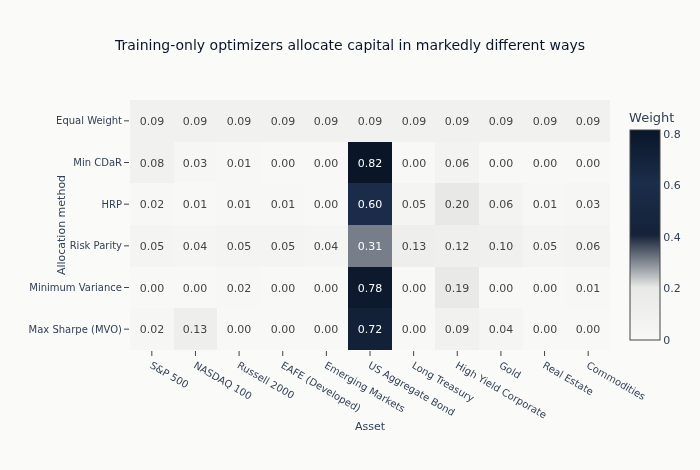

In [14]:
fig = go.Figure(
    data=go.Heatmap(
        z=weight_matrix,
        x=[ETF_UNIVERSE[symbol] for symbol in SYMBOLS],
        y=method_names,
        colorscale=ml4t_palette(5)[::-1],
        zmin=0,
        zmax=float(weight_matrix.max()),
        text=np.round(weight_matrix, 2),
        texttemplate="%{text:.2f}",
        colorbar=dict(title="Weight"),
    )
)
fig.update_layout(
    title="Training-only optimizers allocate capital in markedly different ways",
    xaxis_title="Asset",
    yaxis_title="Allocation method",
    height=470,
    margin=dict(l=130, b=120, r=40),
)
fig.show()

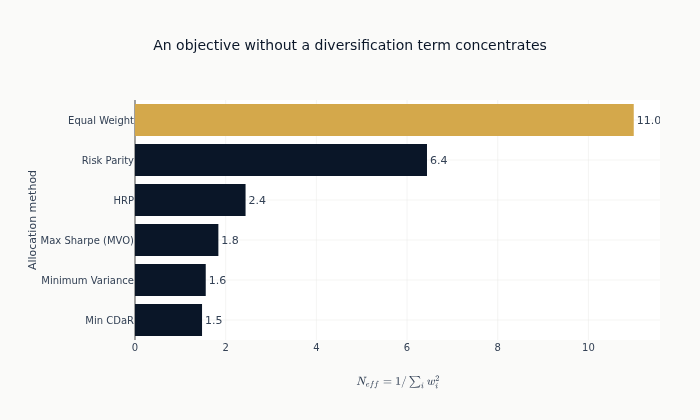

In [15]:
concentration_order = sorted(effective_n, key=effective_n.get)
fig = go.Figure(
    go.Bar(
        x=[effective_n[name] for name in concentration_order],
        y=concentration_order,
        orientation="h",
        marker_color=[
            COLORS["amber"] if name == "Equal Weight" else COLORS["blue"]
            for name in concentration_order
        ],
        text=[f"{effective_n[name]:.1f}" for name in concentration_order],
        textposition="outside",
    )
)
fig.update_layout(
    title="An objective without a diversification term concentrates",
    xaxis_title=r"Effective positions, $N_{eff}=1/\sum_i w_i^2$",
    yaxis_title="Allocation method",
    height=420,
    showlegend=False,
    margin=dict(l=135, r=40),
)
fig.show()

In [16]:
for name, positions in sorted(effective_n.items(), key=lambda item: item[1]):
    print(
        f"{name:<20} {positions:5.2f} effective positions, largest weight {top_weights[name]:.1%}"
    )

Min CDaR              1.48 effective positions, largest weight 81.5%
Minimum Variance      1.56 effective positions, largest weight 77.7%
Max Sharpe (MVO)      1.84 effective positions, largest weight 71.8%
HRP                   2.44 effective positions, largest weight 60.1%
Risk Parity           6.44 effective positions, largest weight 31.3%
Equal Weight         11.00 effective positions, largest weight 9.1%


Effective positions is the inverse of the sum of squared weights: an allocation split evenly
across five assets has five, one that puts everything in a single asset has one.

The ordering is not the one the previous notebook would suggest. Dropping the expected-return
vector does not fix concentration: minimum variance and minimum conditional drawdown hold *fewer*
effective positions than maximum Sharpe, because an objective that minimizes a risk number loads
into the single lowest-risk asset exactly as hard as one that maximizes a return ratio loads into
the highest-return one. Both are corner solutions of an objective with nothing pulling the other
way.

What separates the top of this list from the bottom is whether diversification is in the
objective at all. Risk parity requires every asset to contribute equally to risk, so it cannot
put most of the book in one name. Hierarchical risk parity splits the budget down a tree of correlation clusters,
which spreads it less evenly but still spreads it. Equal weight assumes the answer. Estimating
less is worth doing for stability, and it is a different thing from being diversified.

## 6. Backtest Each Portfolio

In [17]:
def backtest_portfolio(weights: dict[str, float], evaluation_returns: pd.DataFrame) -> pd.Series:
    """Apply frozen symbol-keyed target weights to each evaluation-period return."""
    weight_series = pd.Series(
        {symbol: float(weights[symbol]) for symbol in evaluation_returns.columns},
        dtype=float,
    )
    return evaluation_returns @ weight_series


# Apply every frozen allocation to the later test returns without selecting a method.
portfolio_returns = {}
for method, result in results.items():
    port_ret = backtest_portfolio(result["weights"], test_returns)
    portfolio_returns[result["name"]] = port_ret

returns_df = pd.DataFrame(portfolio_returns)
print(f"Frozen-weight test: {returns_df.index[0].date()} to {returns_df.index[-1].date()}")

Frozen-weight test: 2020-01-02 to 2023-12-29


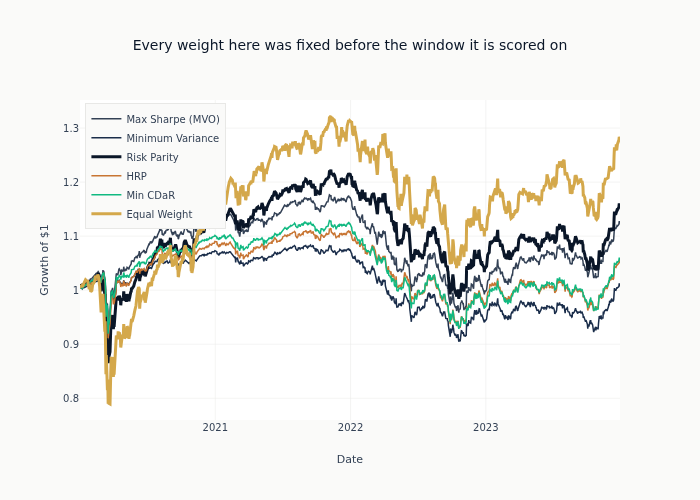

In [18]:
cumulative = (1 + returns_df).cumprod()
fig = go.Figure()
method_colors = {
    "Max Sharpe (MVO)": COLORS["neutral"],
    "Minimum Variance": COLORS["slate"],
    "Risk Parity": COLORS["blue"],
    "HRP": COLORS["copper"],
    "Min CDaR": COLORS["positive"],
    "Equal Weight": COLORS["amber"],
}
for col in cumulative.columns:
    fig.add_trace(
        go.Scatter(
            x=cumulative.index,
            y=cumulative[col],
            name=col,
            line=dict(
                color=method_colors[col],
                width=3 if col in {"Risk Parity", "Equal Weight"} else 1.5,
            ),
        )
    )

final_growth = cumulative.iloc[-1]
growth_leader = str(final_growth.idxmax())
fig.update_layout(
    title="Every weight here was fixed before the window it is scored on",
    xaxis_title="Date",
    yaxis_title="Growth of $1",
    height=500,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01, bgcolor=COLORS["bg_light"]),
)
fig.show()

## 7. Performance Comparison

In [19]:
# Compute numeric test metrics for each frozen portfolio.
metrics_data = []

for name, ret in portfolio_returns.items():
    analysis = PortfolioAnalysis(
        returns=ret.values,
        risk_free=0.0,
        periods_per_year=252,
    )
    metrics = analysis.compute_summary_stats()

    metrics_data.append(
        {
            "portfolio": name,
            "annual_return": metrics.annual_return,
            "annual_volatility": metrics.annual_volatility,
            "sharpe": metrics.sharpe_ratio,
            "sortino": metrics.sortino_ratio,
            "max_drawdown": metrics.max_drawdown,
            "calmar": metrics.calmar_ratio,
        }
    )

metrics_df = pl.DataFrame(metrics_data).sort("sharpe", descending=True)
metrics_df

portfolio,annual_return,annual_volatility,sharpe,sortino,max_drawdown,calmar
str,f64,f64,f64,f64,f64,f64
"""Equal Weight""",0.062757,0.147861,0.486009,0.6632,-0.232698,0.269693
"""Risk Parity""",0.036118,0.101922,0.399239,0.54395,-0.195699,0.184557
"""Max Sharpe (MVO)""",0.029425,0.081478,0.396781,0.54414,-0.185151,0.158927
"""Min CDaR""",0.013639,0.075194,0.217871,0.29398,-0.177624,0.076785
"""HRP""",0.01232,0.075384,0.200216,0.272611,-0.167094,0.073734
"""Minimum Variance""",0.001832,0.070555,0.061318,0.082546,-0.16527,0.011087


Every figure here is computed on the test window under a zero risk-free hurdle, from weights
fitted before it and never adjusted afterwards. That makes the comparison fair between the
allocations and still leaves it a description of one historical period: an allocation that leads
this table was not selected for leading it, and nothing here estimates how it would rank on a
different window.

The vectorized path restores frozen risk-parity targets every day at close-to-close
returns. Two engine paths submit the same daily targets on actual test-period OHLCV.
The zero-cost path isolates next-bar timing and engine mechanics; the second adds costs.

In [20]:
class DailyTargetWeightStrategy(Strategy):
    def __init__(self, target_weights: dict[str, float], allow_short: bool):
        self.target_weights = target_weights
        self.executor = TargetWeightExecutor(
            config=RebalanceConfig(
                min_trade_value=0.0,
                min_weight_change=0.0,
                allow_fractional=True,
                allow_short=allow_short,
            )
        )

    def on_data(self, timestamp, data, context, broker):
        targets = {asset: weight for asset, weight in self.target_weights.items() if asset in data}
        if targets:
            self.executor.execute(targets, data, broker)

In [21]:
# Prepare actual post-training OHLCV and the train-fitted risk-parity target.
bridge_name = "Risk Parity"
engine_target_weights = {
    symbol: float(results["risk_parity"]["weights"][symbol]) for symbol in SYMBOLS
}
allow_short_engine = any(weight < 0 for weight in engine_target_weights.values())
test_prices_long = (
    etf_data.filter(pl.col("timestamp") > pl.lit(TRAIN_END).str.to_date())
    .select(["timestamp", "symbol", "open", "high", "low", "close", "volume"])
    .drop_nulls()
    .with_columns(pl.col("timestamp").cast(pl.Datetime("us")))
    .sort(["timestamp", "symbol"])
)

Run the daily-target engine under zero costs and under the declared 5 bp commission
plus 5 bp slippage assumptions.

In [22]:
def run_daily_target_engine(*, cost_aware: bool, return_column: str) -> pl.DataFrame:
    """Run daily target rebalancing with or without explicit trading costs."""
    engine = Engine(
        feed=DataFeed(prices_df=test_prices_long),
        strategy=DailyTargetWeightStrategy(
            engine_target_weights,
            allow_short=allow_short_engine,
        ),
        config=BacktestConfig(
            initial_cash=100_000.0,
            execution_mode=ExecutionMode.NEXT_BAR,
            commission_type=CommissionType.PERCENTAGE if cost_aware else CommissionType.NONE,
            commission_rate=COMMISSION_RATE if cost_aware else 0.0,
            slippage_type=SlippageType.PERCENTAGE if cost_aware else SlippageType.NONE,
            slippage_rate=SLIPPAGE_RATE if cost_aware else 0.0,
            allow_short_selling=allow_short_engine,
        ),
    )
    return (
        engine.run()
        .to_daily_pnl()
        .select(
            pl.col("date").cast(pl.Datetime("us")).alias("timestamp"),
            pl.col("return_pct").alias(return_column),
        )
    )

The two engine runs differ only in whether costs are charged, so the difference between them is
the cost and nothing else.

In [23]:
zero_cost_daily = run_daily_target_engine(
    cost_aware=False,
    return_column="zero_cost_return",
)
cost_aware_daily = run_daily_target_engine(
    cost_aware=True,
    return_column="cost_aware_return",
)

vectorized_daily = pl.DataFrame(
    {
        "timestamp": pl.Series(returns_df.index.to_list()).cast(pl.Datetime("us")),
        "vectorized_return": portfolio_returns[bridge_name].to_numpy(),
    }
)

In [24]:
# Compare all three paths only on common test dates.
bridge = (
    vectorized_daily.join(zero_cost_daily, on="timestamp", how="inner")
    .join(cost_aware_daily, on="timestamp", how="inner")
    .drop_nulls(["vectorized_return", "zero_cost_return", "cost_aware_return"])
    .sort("timestamp")
)

bridge_stats = {}
for label, column in {
    "Vectorized": "vectorized_return",
    "Zero-cost engine": "zero_cost_return",
    "Cost-aware engine": "cost_aware_return",
}.items():
    analysis = PortfolioAnalysis(
        returns=bridge[column],
        dates=bridge["timestamp"],
        risk_free=0.0,
        periods_per_year=252,
    )
    bridge_stats[label] = analysis.compute_summary_stats()

print("Execution bridge (train-only risk parity, daily target rebalancing):")
for label, stats in bridge_stats.items():
    print(
        f"  {label}: Sharpe={stats.sharpe_ratio:.3f}, "
        f"MaxDD={stats.max_drawdown:.2%}, Annual Return={stats.annual_return:.2%}"
    )

Execution bridge (train-only risk parity, daily target rebalancing):
  Vectorized: Sharpe=0.399, MaxDD=-19.57%, Annual Return=3.61%
  Zero-cost engine: Sharpe=0.367, MaxDD=-19.67%, Annual Return=3.27%
  Cost-aware engine: Sharpe=0.359, MaxDD=-19.71%, Annual Return=3.18%


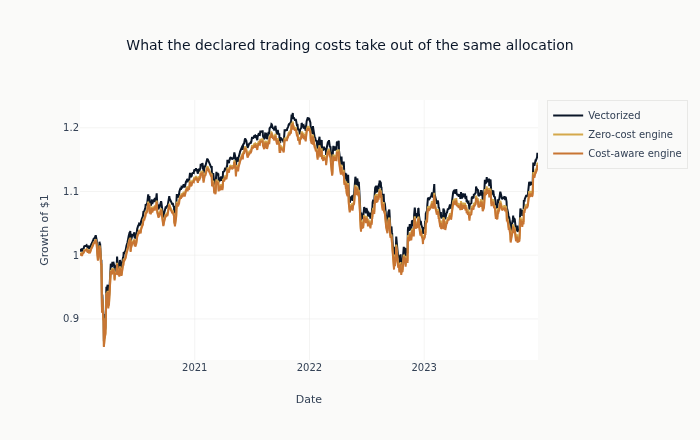

In [25]:
fig = go.Figure()
bridge_columns = {
    "Vectorized": "vectorized_return",
    "Zero-cost engine": "zero_cost_return",
    "Cost-aware engine": "cost_aware_return",
}
bridge_colors = {
    "Vectorized": COLORS["blue"],
    "Zero-cost engine": COLORS["amber"],
    "Cost-aware engine": COLORS["copper"],
}
for label, column in bridge_columns.items():
    fig.add_scatter(
        x=bridge["timestamp"],
        y=(1 + bridge[column]).cum_prod(),
        mode="lines",
        name=label,
        line=dict(color=bridge_colors[label]),
    )

annual_cost_gap = (
    bridge_stats["Zero-cost engine"].annual_return - bridge_stats["Cost-aware engine"].annual_return
)
fig.update_layout(
    title="What the declared trading costs take out of the same allocation",
    xaxis_title="Date",
    yaxis_title="Growth of $1",
    height=440,
    legend=dict(bgcolor=COLORS["bg_light"]),
)
fig.show()

Vectorized versus zero-cost differences reflect next-bar timing and engine mechanics.
Zero-cost versus cost-aware differences isolate the declared costs under the same targets.

In [26]:
# Build the risk-return inputs before plotting the frontier-style comparison.
risk_return_data = []
for name, ret in portfolio_returns.items():
    ret_arr = ret.to_numpy(dtype=float)
    ann_ret = float(np.mean(ret_arr) * 252)
    ann_vol = float(np.std(ret_arr, ddof=1) * np.sqrt(252)) if len(ret_arr) > 1 else 0.0
    risk_return_data.append(
        {
            "name": name,
            "return": ann_ret * 100,
            "volatility": ann_vol * 100,
        }
    )

rr_df = pl.DataFrame(risk_return_data)

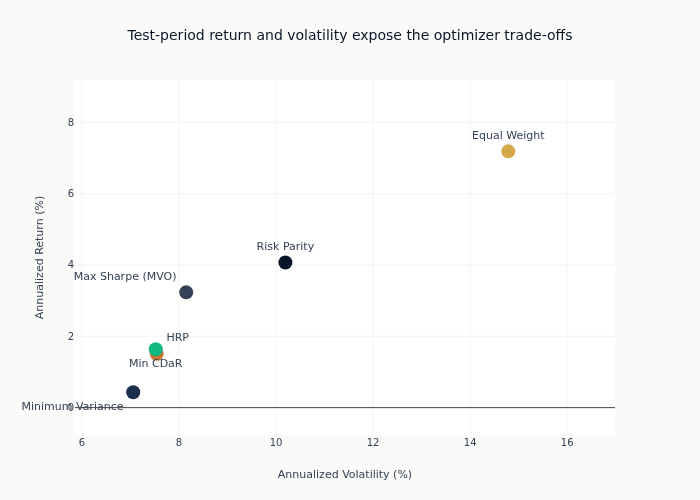

In [27]:
fig = go.Figure()
text_positions = {
    "Max Sharpe (MVO)": "top left",
    "Minimum Variance": "bottom left",
    "Risk Parity": "top center",
    "HRP": "top right",
    "Min CDaR": "bottom center",
    "Equal Weight": "top center",
}
for row in rr_df.iter_rows(named=True):
    name = row["name"]
    fig.add_scatter(
        x=[row["volatility"]],
        y=[row["return"]],
        text=[name],
        mode="markers+text",
        textposition=text_positions[name],
        cliponaxis=False,
        marker=dict(size=14, color=method_colors[name]),
        name=name,
        showlegend=False,
    )

x_min, x_max = rr_df["volatility"].min(), rr_df["volatility"].max()
y_min, y_max = rr_df["return"].min(), rr_df["return"].max()
fig.update_layout(
    title="Test-period return and volatility expose the optimizer trade-offs",
    xaxis_title="Annualized Volatility (%)",
    yaxis_title="Annualized Return (%)",
    height=500,
    xaxis_range=[x_min - 1.2, x_max + 2.2],
    yaxis_range=[y_min - 1.2, y_max + 2.0],
    margin=dict(l=75, r=85, t=80, b=65),
)

fig.show()

The test window for every allocation fitted on the training window. The ordering describes this
split and was not used to retune anything.

## 8. Drawdown Comparison

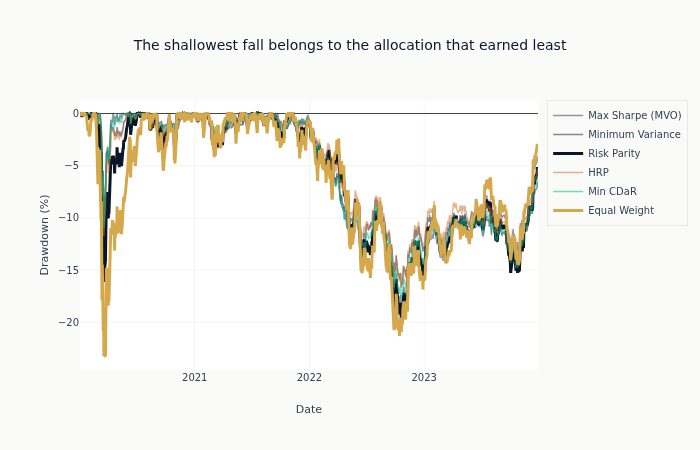

In [28]:
# Compute drawdowns
def compute_drawdown(returns: pd.Series) -> pd.Series:
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.expanding().max()
    return (cumulative - running_max) / running_max


drawdowns = pd.DataFrame({name: compute_drawdown(ret) for name, ret in portfolio_returns.items()})

fig = go.Figure()

for col in drawdowns.columns:
    fig.add_trace(
        go.Scatter(
            x=drawdowns.index,
            y=drawdowns[col] * 100,
            name=col,
            opacity=1.0 if col in {"Risk Parity", "Equal Weight"} else 0.55,
            line=dict(
                color=method_colors[col],
                width=3 if col in {"Risk Parity", "Equal Weight"} else 1.5,
            ),
        )
    )

max_drawdowns = drawdowns.min()
shallowest_name = str(max_drawdowns.idxmax())
fig.update_layout(
    title="The shallowest fall belongs to the allocation that earned least",
    xaxis_title="Date",
    yaxis_title="Drawdown (%)",
    height=450,
    legend=dict(bgcolor=COLORS["bg_light"]),
)
fig.show()

Zero is each allocation's own running peak, so every curve is at or below it. Read it against
the Sharpe column above and the trade is plain: the allocation with the shallowest fall is also
the one that earned least, and the one that earned most fell furthest. Nothing here is free, and
which end of that trade a holder wants is not a question the data answers.

## 9. Risk Contribution Analysis

An asset's **risk contribution** is its weight times its marginal effect on portfolio variance,
divided by the total: the share of the portfolio's variance that asset is responsible for. Risk
parity is defined by making those shares equal, so the chart below is that definition evaluated.
The other allocations carry no such constraint, and where their capital concentrates their risk
concentrates further - variance is quadratic in the weights, so doubling a weight roughly
quadruples what it contributes.

In [29]:
def compute_risk_contribution(weights: dict[str, float], covariance: pd.DataFrame) -> pd.Series:
    """Compute percentage variance contributions under a supplied covariance model."""
    symbols = list(covariance.columns)
    w = pd.Series({symbol: float(weights[symbol]) for symbol in symbols}, dtype=float)
    cov = covariance.loc[symbols, symbols]
    port_var = float(w @ cov @ w)
    if port_var <= 0:
        return pd.Series(0.0, index=w.index)
    marginal = cov @ w
    return w * marginal / port_var

In [30]:
# Use the exact fitted Ledoit-Wolf covariance retained by each Riskfolio optimizer.
rc_methods = ["max_sharpe", "risk_parity", "min_variance"]
rc_table = pd.DataFrame(
    {
        results[m]["name"]: compute_risk_contribution(
            results[m]["weights"], results[m]["covariance"]
        )
        * 100
        for m in rc_methods
        if m in results
    }
)
rc_table = rc_table.reindex(SYMBOLS)
if not np.allclose(rc_table["Risk Parity"].sum(), 100.0, atol=1e-6):
    raise ValueError("Risk-parity contribution shares do not sum to 100%")

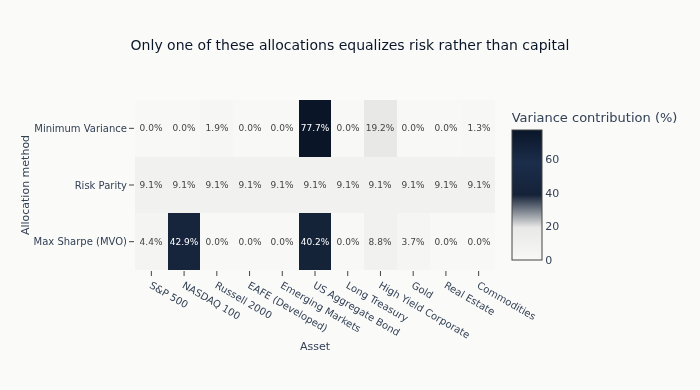

In [31]:
rc_values = rc_table.to_numpy().T
target_contribution = 100 / len(SYMBOLS)
rp_max_deviation = float(np.abs(rc_table["Risk Parity"].to_numpy() - target_contribution).max())
fig = go.Figure(
    data=go.Heatmap(
        z=rc_values,
        x=[ETF_UNIVERSE[symbol] for symbol in SYMBOLS],
        y=list(rc_table.columns),
        colorscale=ml4t_palette(5)[::-1],
        zmin=0,
        zmax=float(np.nanmax(rc_values)),
        text=np.round(rc_values, 1),
        texttemplate="%{text:.1f}%",
        colorbar=dict(title="Variance contribution (%)"),
    )
)
fig.update_layout(
    title="Only one of these allocations equalizes risk rather than capital",
    xaxis_title="Asset",
    yaxis_title="Allocation method",
    height=390,
    margin=dict(l=135, b=120, r=40),
)
fig.show()

Risk parity is checked against the same Ledoit-Wolf covariance that generated its
weights. Max Sharpe and minimum variance expose how capital concentration can become
even more concentrated in variance contribution.

A diagonal-covariance microcase provides a second implementation of equal-risk
contribution: inverse-volatility weights must contribute exactly one third each.

In [32]:
oracle_covariance = pd.DataFrame(
    np.diag([0.04, 0.09, 0.16]),
    index=["A", "B", "C"],
    columns=["A", "B", "C"],
)
oracle_raw_weights = 1 / np.sqrt(np.diag(oracle_covariance))
oracle_raw_weights /= oracle_raw_weights.sum()
oracle_weights = dict(zip(oracle_covariance.columns, oracle_raw_weights, strict=True))
oracle_contributions = compute_risk_contribution(oracle_weights, oracle_covariance)
np.testing.assert_allclose(oracle_contributions.to_numpy(), np.repeat(1 / 3, 3), atol=1e-12)
print(f"Diagonal-covariance ERC oracle: max error={abs(oracle_contributions - 1 / 3).max():.2e}")

Diagonal-covariance ERC oracle: max error=1.11e-16


## 10. Rolling Performance

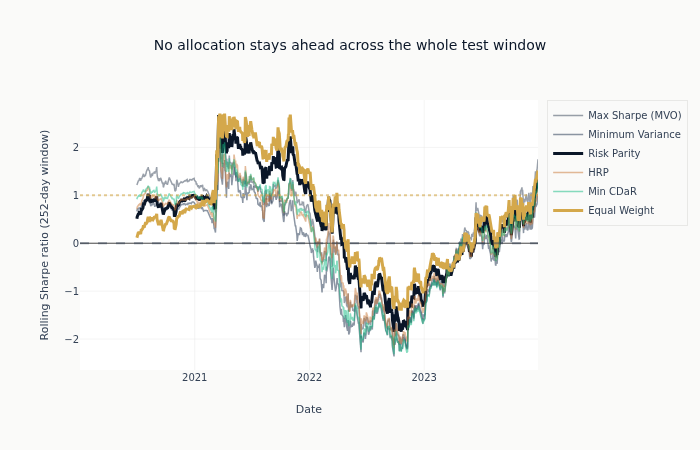

In [33]:
# Compute 252-day rolling Sharpe with at least 126 observations.
window = 252
rolling_sharpe = pd.DataFrame()

for name, ret in portfolio_returns.items():
    rolling_mean = ret.rolling(window, min_periods=126).mean()
    rolling_std = ret.rolling(window, min_periods=126).std()
    rolling_sharpe[name] = (rolling_mean / rolling_std) * np.sqrt(252)

# Plot
fig = go.Figure()

for col in rolling_sharpe.columns:
    fig.add_trace(
        go.Scatter(
            x=rolling_sharpe.index,
            y=rolling_sharpe[col],
            name=col,
            opacity=1.0 if col in {"Risk Parity", "Equal Weight"} else 0.5,
            line=dict(
                color=method_colors[col],
                width=3 if col in {"Risk Parity", "Equal Weight"} else 1.5,
            ),
        )
    )

fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], opacity=0.5)
fig.add_hline(y=1, line_dash="dot", line_color=COLORS["amber"], opacity=0.6)

fig.update_layout(
    title="No allocation stays ahead across the whole test window",
    xaxis_title="Date",
    yaxis_title="Rolling Sharpe ratio (252-day window)",
    height=450,
    legend=dict(bgcolor=COLORS["bg_light"]),
)
fig.show()

Rolling estimates use a 252-trading-day window, a 126-observation minimum, daily
returns, and square-root-of-252 annualization. They diagnose stability rather than
provide another selection criterion.

In [34]:
test_sharpes = {row["portfolio"]: row["sharpe"] for row in metrics_df.iter_rows(named=True)}
test_drawdowns = {row["portfolio"]: row["max_drawdown"] for row in metrics_df.iter_rows(named=True)}
for name, sharpe in sorted(test_sharpes.items(), key=lambda item: -item[1]):
    print(f"{name:<22} Sharpe {sharpe:6.3f}   max drawdown {test_drawdowns[name]:7.1%}")
print(
    f"{'Risk parity, with costs':<22} Sharpe {bridge_stats['Cost-aware engine'].sharpe_ratio:6.3f}"
)

Equal Weight           Sharpe  0.486   max drawdown  -23.3%
Risk Parity            Sharpe  0.399   max drawdown  -19.6%
Max Sharpe (MVO)       Sharpe  0.397   max drawdown  -18.5%
Min CDaR               Sharpe  0.218   max drawdown  -17.8%
HRP                    Sharpe  0.200   max drawdown  -16.7%
Minimum Variance       Sharpe  0.061   max drawdown  -16.5%
Risk parity, with costs Sharpe  0.359


The last row is the one to read against the first. It is the same risk-parity allocation put
through an engine that charges the declared commission and slippage, and the difference between
the two is what implementing the allocation costs. Any ranking computed above it is a ranking of
paper portfolios.

### What this run produced

Three tables carry it, and they answer different questions. The weight comparison says where
each method put capital; the effective-positions column beside it says how concentrated that is
as a number rather than by eye. The performance table scores the six frozen allocations on the
test window. The execution bridge at the end repeats one of them - risk parity - through an
engine that charges the declared commission and slippage, so the gap between its last row and
the paper figure above is what implementing that allocation costs.

The ordering in the performance table describes this split. No allocation was retuned against
it, and nothing here estimates how the same six would rank on a different train/test cut.

## Key takeaways

1. **Dropping the expected-return estimate buys stability, not diversification.** Minimum
   variance and minimum conditional drawdown use no return forecast and still concentrate harder
   than maximum Sharpe does, because minimizing a risk number is as much a corner solution as
   maximizing a ratio. What keeps an allocation spread out is a diversification requirement
   inside the objective, which is what risk parity has and the minimizers do not.
2. **Shrinking the covariance is a bias-for-variance trade, made deliberately.** Ledoit-Wolf
   pulls the sample matrix towards a structured target, so it is wrong in a known direction and
   less wrong from one sample to the next. The reason to accept the bias is that the optimizer
   inverts this matrix and inversion punishes variance far more than bias.
3. **Risk parity equalizes risk, not capital, and only against the covariance it was fitted
   on.** The risk-contribution chart shows it holding within a small tolerance in sample; whether
   the contributions stay equal out of sample is a different question and depends on whether the
   correlations did.
4. **Targeting a drawdown in training does not deliver one in testing.** Minimum CDaR optimizes
   the tail it was shown. Read its test drawdown against the others before concluding the
   protection transferred.
5. **Effective positions makes concentration a number.** It is a better basis for an argument
   than looking at a bar chart, and it is one of the few diagnostics here that needs no return
   estimate at all.
6. **Report the cost-aware run beside the paper one.** Timing and fees are separate mechanisms
   and both are declared; an allocation ranking computed without them is a ranking of portfolios
   nobody can hold.

### Known limitations

- One training window, one test window, one universe of eleven funds. A different split date
  would refit every allocation and could reorder the table.
- Weights are frozen across the test window and rebalanced daily to target. A real
  implementation would re-estimate periodically, which adds turnover and a fresh estimation
  error at each step.
- Long-only and fully invested throughout, which is what keeps the maximum-Sharpe concentration
  as mild as it appears.
- The risk-free hurdle is zero, so every Sharpe here is a raw return-to-risk ratio rather than an
  excess-return one.

**Next:** [`04_kelly_criterion`](04_kelly_criterion.ipynb) turns from which assets to hold to how
much of the portfolio to put at risk. Section 17.5 covers the Markowitz curse and the robust
estimators used here.